# Thermodynamics & Statistical Mechanics — Simulation Project

**Universitat Autònoma de Barcelona** · BSc in Physics · *Termodinàmica i Mecànica Estadística* · May 2026
**Authors:** Arnau Núñez Martínez, Arnau Viladevall Ferré

This notebook contains the numerical analysis of the project: the **isothermal compressibility of a Lennard-Jones fluid** (Part A) and a **Metropolis Monte Carlo simulation of a three-level canonical system** (Part B). The hard-sphere gas simulations (VPython) are standalone scripts in [`src/hard_sphere_gas/`](../src/hard_sphere_gas).

| Report question | Topic | Where |
|---|---|---|
| Q1–Q3 | Hard-sphere gas: atom size, Andersen thermostat (canonical ensemble), gravitational field | `src/hard_sphere_gas/` (VPython scripts) |
| Q4 | Lennard-Jones fluid at fixed $(N,\rho,T)$: hysteresis and metastability | Course-provided simulator (no code in this repository) — see the report |
| Q5 | Isothermal compressibility of the LJ gas and liquid | **Part A** |
| Q6–Q8 | Three-level system: Metropolis algorithm, level populations, energy fluctuations | **Part B** |

All quantities in Parts A and B are in reduced units ($k_B = \varepsilon = \sigma = 1$).

## Setup

In [1]:
import os
import time

import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = "../figures"          # figures are saved next to the notebook folder
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

SEED = 2026                     # master seed -> every random number below is reproducible
print(f"NumPy {np.__version__}")

NumPy 2.4.4


## Part A — Isothermal compressibility of a Lennard-Jones fluid (Q5)

The isothermal compressibility measures how much the volume of a system changes under a pressure change at constant temperature:

$$\kappa_T = -\frac{1}{V}\left(\frac{\partial V}{\partial P}\right)_T .$$

The simulations were run in the **canonical (NVT) ensemble** with $N = 500$ particles: $T$ and $V$ are set and the simulator returns the pressure $P$ (with a statistical error). Changing $V$ changes $\rho = N/V$, so $\kappa_T$ can be written in terms of the measured equation of state $P(\rho)$:

$$\kappa_T = \frac{1}{\rho}\left(\frac{\partial \rho}{\partial P}\right)_T = \frac{1}{\rho\,(\partial P/\partial\rho)_T}.$$

For an ideal gas $P = \rho T$ (with $k_B = 1$), hence $\kappa_T^{\rm ideal} = 1/P = 1/(\rho T)$.

**Method.**
- *Gas* ($\rho \lesssim 0.1$): $\partial P/\partial\rho$ is the least-squares slope of $P(\rho)$ at each temperature, and $\kappa_T = 1/(\bar\rho\,\partial P/\partial\rho)$ with $\bar\rho$ the mean density of the points used. The ideal-gas value is evaluated at the same $\bar\rho$.
- *Liquid* ($0.55 \lesssim \rho \lesssim 0.86$): finite differences $\Delta P/\Delta\rho$ between consecutive densities, evaluated at the midpoint density. Intervals with a non-positive slope are discarded because $\kappa_T$ must be positive; they are counted explicitly below.
- *Uncertainties* (added in this notebook): the pressure errors given by the simulator are propagated to the slope and then to $\kappa_T$.

### Simulation data

In [2]:
# Pressure P (reduced units) measured at fixed N = 500 and V = N / rho for several (T, rho).
# dP is the statistical uncertainty reported by the simulator.

# ---- Gas phase (low density) ----
GAS = {
    0.8: dict(rho=[0.003, 0.004],                P=[0.0020, 0.0030],                dP=[0.0005, 0.0005]),
    1.0: dict(rho=[0.010, 0.020, 0.030, 0.040],  P=[0.009, 0.018, 0.025, 0.032],    dP=[0.001, 0.001, 0.002, 0.003]),
    1.2: dict(rho=[0.040, 0.060, 0.080, 0.100],  P=[0.041, 0.056, 0.069, 0.078],    dP=[0.005, 0.005, 0.008, 0.011]),
    1.4: dict(rho=[0.020, 0.040, 0.080, 0.100],  P=[0.026, 0.050, 0.088, 0.105],    dP=[0.001, 0.003, 0.008, 0.011]),
}

# ---- Liquid phase (high density) ----
LIQUID = {
    0.8: dict(rho=[0.820, 0.840, 0.860], P=[0.287, 0.589, 0.763], dP=[0.18, 0.19, 0.43]),
    1.0: dict(rho=[0.547, 0.647, 0.747], P=[0.205, 0.204, 0.387], dP=[0.12, 0.14, 0.18]),
    1.2: dict(rho=[0.547, 0.647, 0.747], P=[0.061, 0.321, 1.134], dP=[0.13, 0.17, 0.21]),
    1.4: dict(rho=[0.547, 0.647, 0.747], P=[0.377, 0.818, 1.864], dP=[0.14, 0.18, 0.24]),
}

# T = 0.8, rho <= 0.747: negative / erratic pressures (metastable or noisy states).
# Kept only to illustrate the problem in the equation-of-state plot; never used to compute kappa_T.
LIQUID_T08_UNRELIABLE = dict(rho=[0.547, 0.647, 0.747], P=[-0.426, -0.674, -0.435])

### Analysis functions

In [3]:
def ols_slope(rho, P, dP):
    """Least-squares slope dP/drho and its uncertainty.

    The slope is the ordinary (unweighted) least-squares estimate. Its uncertainty comes from
    propagating the known pressure errors: Var(slope) = sum[(x_i - xbar)^2 sigma_i^2] / [sum (x_i - xbar)^2]^2.
    """
    rho, P, dP = map(np.asarray, (rho, P, dP))
    dx = rho - rho.mean()
    slope = np.sum(dx * (P - P.mean())) / np.sum(dx**2)
    slope_err = np.sqrt(np.sum(dx**2 * dP**2)) / np.sum(dx**2)
    return slope, slope_err


def gas_compressibility(data):
    """kappa_T = 1 / (rho_mean * dP/drho) from a linear fit of P(rho); ideal gas: kappa_T = 1 / (rho T)."""
    rows = []
    for T, d in sorted(data.items()):
        rho = np.asarray(d["rho"])
        slope, slope_err = ols_slope(rho, d["P"], d["dP"])
        rho_mean = rho.mean()
        kappa = 1.0 / (rho_mean * slope)
        kappa_err = slope_err / (rho_mean * slope**2)
        kappa_ideal = 1.0 / (rho_mean * T)
        rows.append(dict(T=T, rho_mean=rho_mean, slope=slope, kappa=kappa,
                         kappa_err=kappa_err, kappa_ideal=kappa_ideal))
    return rows


def liquid_compressibility(data):
    """Local finite-difference estimates of kappa_T between consecutive densities.

    Intervals with a non-positive slope are discarded (kappa_T must be positive); they are counted
    so the selection is visible. 'mean'/'std' reproduce the per-temperature summary used in the report.
    """
    out = {}
    for T, d in sorted(data.items()):
        rho, P, dP = map(np.asarray, (d["rho"], d["P"], d["dP"]))
        local, discarded = [], 0
        for i in range(len(rho) - 1):
            drho = rho[i + 1] - rho[i]
            slope = (P[i + 1] - P[i]) / drho
            slope_err = np.hypot(dP[i], dP[i + 1]) / drho
            rho_loc = 0.5 * (rho[i] + rho[i + 1])
            if slope > 0:
                local.append(dict(rho=rho_loc, kappa=1.0 / (rho_loc * slope),
                                  kappa_err=slope_err / (rho_loc * slope**2)))
            else:
                discarded += 1
        k = np.array([x["kappa"] for x in local])
        out[T] = dict(local=local, discarded=discarded, mean=k.mean(), std=k.std())
    return out

### Gas phase

   T   <rho>   dP/drho      kappa_sim  kappa_ideal  ratio
 0.8  0.0035     1.000   285.7 +/-202.0        357.1   0.80
 1.0  0.0250     0.760    52.6 +/-  6.7         40.0   1.32
 1.2  0.0700     0.620    23.0 +/-  7.0         11.9   1.94
 1.4  0.0600     0.980    17.0 +/-  2.1         11.9   1.43


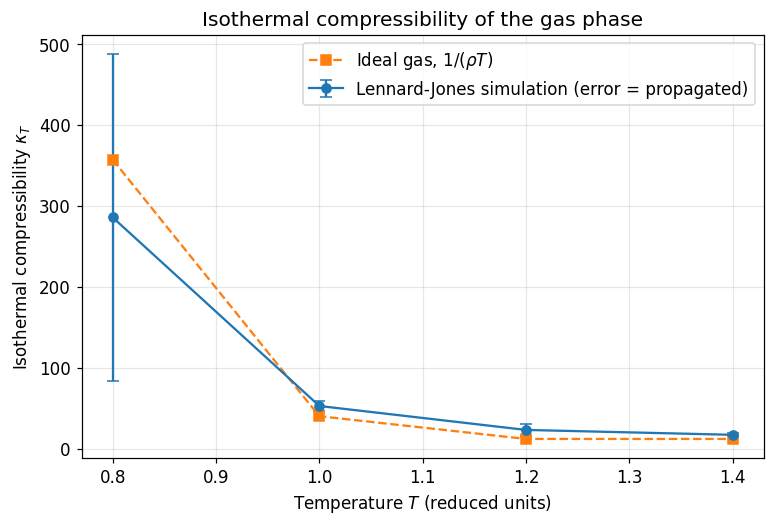

In [4]:
gas = gas_compressibility(GAS)

print(f"{'T':>4} {'<rho>':>7} {'dP/drho':>9} {'kappa_sim':>14} {'kappa_ideal':>12} {'ratio':>6}")
for r in gas:
    print(f"{r['T']:4.1f} {r['rho_mean']:7.4f} {r['slope']:9.3f} "
          f"{r['kappa']:7.1f} +/-{r['kappa_err']:5.1f} {r['kappa_ideal']:12.1f} {r['kappa'] / r['kappa_ideal']:6.2f}")

T_g = np.array([r["T"] for r in gas])
fig, ax = plt.subplots()
ax.errorbar(T_g, [r["kappa"] for r in gas], yerr=[r["kappa_err"] for r in gas],
            fmt="o-", capsize=4, label="Lennard-Jones simulation (error = propagated)")
ax.plot(T_g, [r["kappa_ideal"] for r in gas], "s--", label=r"Ideal gas, $1/(\rho T)$")
ax.set_xlabel("Temperature $T$ (reduced units)")
ax.set_ylabel(r"Isothermal compressibility $\kappa_T$")
ax.set_title("Isothermal compressibility of the gas phase")
ax.legend()
fig.savefig(f"{FIG_DIR}/compressibility_gas.png")
plt.show()

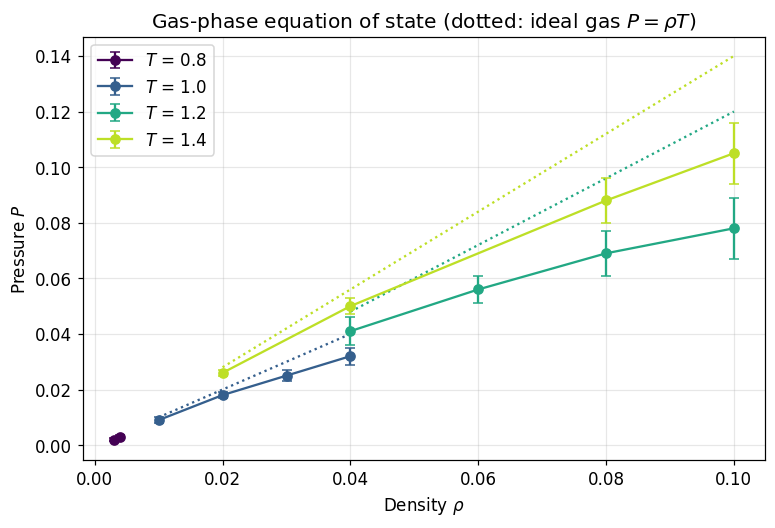

In [5]:
fig, ax = plt.subplots()
for (T, d), c in zip(sorted(GAS.items()), plt.cm.viridis(np.linspace(0, 0.9, len(GAS)))):
    rho = np.array(d["rho"])
    ax.errorbar(rho, d["P"], yerr=d["dP"], fmt="o-", color=c, capsize=3, label=f"$T$ = {T}")
    ax.plot(rho, rho * T, ":", color=c)            # ideal gas P = rho T at the same temperature
ax.set_xlabel(r"Density $\rho$")
ax.set_ylabel("Pressure $P$")
ax.set_title("Gas-phase equation of state (dotted: ideal gas $P=\\rho T$)")
ax.legend()
fig.savefig(f"{FIG_DIR}/eos_gas.png")
plt.show()

**Reading the gas results**

- The simulated $\kappa_T$ follows the ideal-gas trend: it decreases strongly with temperature and is of the same order of magnitude at every temperature, as expected at low density where the pressure is dominated by the kinetic term.
- For $T \ge 1.0$ the simulated value is above the ideal-gas one by a factor of about 1.3–1.9. Each individual ratio is only about 1.5–2.5 propagated standard deviations away from 1, so the evidence is moderate, but the sign is what one expects from the attractive part of the Lennard-Jones potential: attraction lowers $\partial P/\partial\rho$ below its ideal value $T$, which raises $\kappa_T$.
- At $T = 0.8$ the estimate relies on only two points whose pressures carry ~20 % errors, so the slope (and $\kappa_T$) is not significantly different from the ideal value.
- $T = 1.4$ lies close to or above the critical temperature of the LJ fluid ($T_c \approx 1.3$ in these units), where "gas" and "liquid" are only low- and high-density states of a single supercritical fluid.

### Liquid phase

In [6]:
liq = liquid_compressibility(LIQUID)

print("Local finite-difference estimates (positive slopes only)")
print(f"{'T':>4} {'rho_mid':>8} {'kappa_T':>9} {'+/-':>7}")
for T, res in liq.items():
    for x in res["local"]:
        print(f"{T:4.1f} {x['rho']:8.3f} {x['kappa']:9.4f} {x['kappa_err']:7.4f}")
    if res["discarded"]:
        print(f"{T:4.1f}   -> {res['discarded']} interval(s) discarded (non-positive slope)")

print("\nPer-temperature summary (mean and population std of the local estimates)")
for T, res in liq.items():
    print(f"T = {T:.1f}   kappa_T = {res['mean']:.4f} +/- {res['std']:.4f}   (n = {len(res['local'])})")

Local finite-difference estimates (positive slopes only)
   T  rho_mid   kappa_T     +/-
 0.8    0.830    0.0798  0.0691
 0.8    0.850    0.1352  0.3653
 1.0    0.697    0.7840  0.9769
 1.0   -> 1 interval(s) discarded (non-positive slope)
 1.2    0.597    0.6442  0.5303
 1.2    0.697    0.1765  0.0586
 1.4    0.597    0.3798  0.1964
 1.4    0.697    0.1372  0.0393

Per-temperature summary (mean and population std of the local estimates)
T = 0.8   kappa_T = 0.1075 +/- 0.0277   (n = 2)
T = 1.0   kappa_T = 0.7840 +/- 0.0000   (n = 1)
T = 1.2   kappa_T = 0.4104 +/- 0.2339   (n = 2)
T = 1.4   kappa_T = 0.2585 +/- 0.1213   (n = 2)


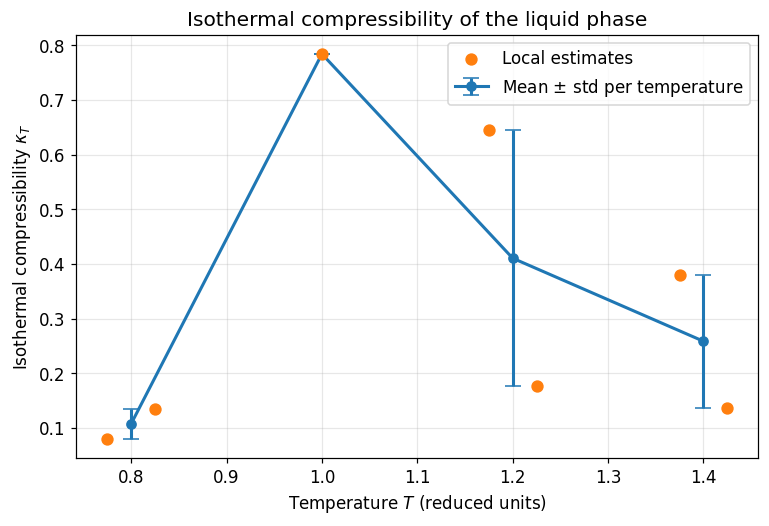

In [7]:
fig, ax = plt.subplots()

# individual local estimates (small horizontal offsets so that points do not overlap)
for T, res in liq.items():
    n = len(res["local"])
    offsets = np.linspace(-0.025, 0.025, n) if n > 1 else [0.0]
    ax.scatter(T + np.array(offsets), [x["kappa"] for x in res["local"]], s=50, zorder=3,
               color="tab:orange", label="Local estimates" if T == 0.8 else None)

T_l = np.array(list(liq.keys()))
ax.errorbar(T_l, [r["mean"] for r in liq.values()], yerr=[r["std"] for r in liq.values()],
            fmt="o-", capsize=5, linewidth=2, color="tab:blue", label="Mean $\\pm$ std per temperature")
ax.set_xlabel("Temperature $T$ (reduced units)")
ax.set_ylabel(r"Isothermal compressibility $\kappa_T$")
ax.set_title("Isothermal compressibility of the liquid phase")
ax.legend()
fig.savefig(f"{FIG_DIR}/compressibility_liquid.png")
plt.show()

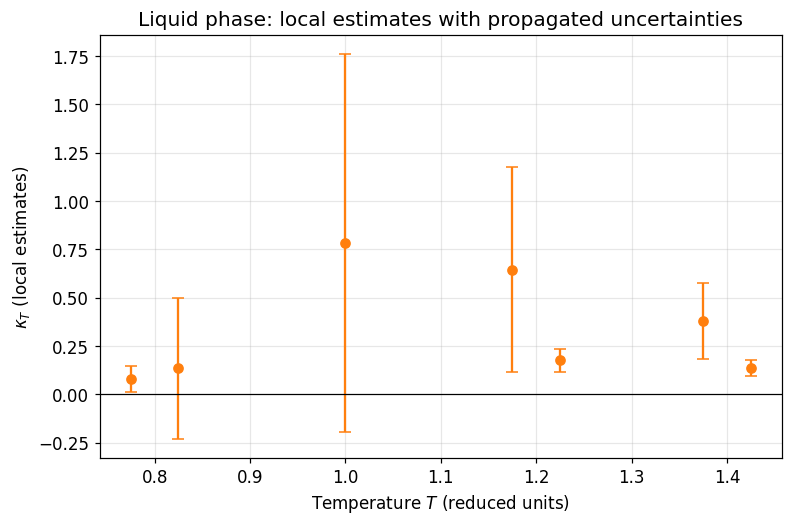

In [8]:
# Supplementary view: each local estimate with its propagated uncertainty.
fig, ax = plt.subplots()
for T, res in liq.items():
    n = len(res["local"])
    offsets = np.linspace(-0.025, 0.025, n) if n > 1 else [0.0]
    ax.errorbar(T + np.array(offsets), [x["kappa"] for x in res["local"]],
                yerr=[x["kappa_err"] for x in res["local"]], fmt="o", capsize=4, color="tab:orange")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel("Temperature $T$ (reduced units)")
ax.set_ylabel(r"$\kappa_T$ (local estimates)")
ax.set_title("Liquid phase: local estimates with propagated uncertainties")
fig.savefig(f"{FIG_DIR}/compressibility_liquid_uncertainties.png")
plt.show()

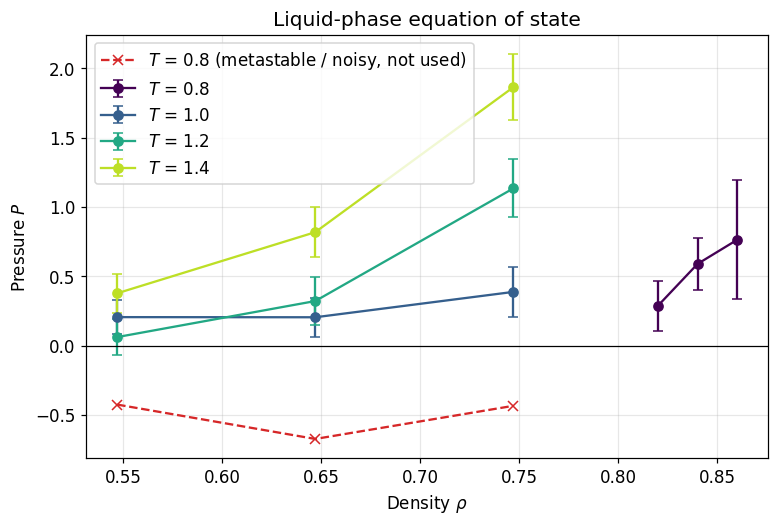

In [9]:
fig, ax = plt.subplots()
for (T, d), c in zip(sorted(LIQUID.items()), plt.cm.viridis(np.linspace(0, 0.9, len(LIQUID)))):
    ax.errorbar(d["rho"], d["P"], yerr=d["dP"], fmt="o-", color=c, capsize=3, label=f"$T$ = {T}")
ax.plot(LIQUID_T08_UNRELIABLE["rho"], LIQUID_T08_UNRELIABLE["P"], "x--", color="tab:red",
        label="$T$ = 0.8 (metastable / noisy, not used)")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel(r"Density $\rho$")
ax.set_ylabel("Pressure $P$")
ax.set_title("Liquid-phase equation of state")
ax.legend()
fig.savefig(f"{FIG_DIR}/eos_liquid.png")
plt.show()

**Reading the liquid results**

- $\kappa_T$ of the liquid is between roughly 0.1 and 0.8 in reduced units, i.e. **at least ~50 times smaller than in the gas at the same temperature**. Compressing a liquid pushes particles into the steep repulsive core of the potential, $V_{\rm rep}\sim(\sigma/r)^{12}$, so the pressure rises very quickly with density.
- The pressure uncertainties are of the same size as the pressure differences between neighbouring densities, so each local estimate carries a large error (see the supplementary figure). The *per-temperature mean ± std* shown in the main figure (as in the report) reflects only the scatter between intervals and **understates** the real uncertainty — in particular at $T = 1.0$, where a single interval survived and the standard deviation is zero by construction.
- Discarding non-positive slopes biases the mean upward, and $T = 0.8$ is dominated by metastable/noisy states (see the equation-of-state plot). The robust conclusion is therefore the large gap $\kappa_T^{\rm gas} \gg \kappa_T^{\rm liquid}$; the apparent trend of the liquid $\kappa_T$ with temperature is not statistically established by these data.

## Part B — Three-level system with the Metropolis algorithm (Q6–Q8)

$N$ independent classical molecules, each with three non-degenerate levels

$$\varepsilon_1 = 0,\qquad \varepsilon_2 = \varepsilon,\qquad \varepsilon_3 = 10\,\varepsilon ,$$

in contact with a thermal bath at temperature $T$ (canonical ensemble). With $k_B = \varepsilon = 1$ the single-molecule partition function and the occupation probabilities are

$$z = 1 + e^{-1/T} + e^{-10/T},\qquad p_0 = \frac1z,\quad p_1 = \frac{e^{-1/T}}{z},\quad p_2 = \frac{e^{-10/T}}{z}.$$

**Metropolis dynamics.** At every Monte Carlo step a molecule is chosen at random and a move to one of the two other levels is proposed with equal probability. With $\Delta E = E_{\rm new} - E_{\rm old}$ the move is accepted with probability $\min\!\big(1, e^{-\Delta E/T}\big)$. The proposal is symmetric, so the chain satisfies detailed balance with respect to the Boltzmann distribution.

**Implementation note.** The molecules are independent, so it is enough to track how many are in each level; the total energy follows as $E = \sum_i N_i \varepsilon_i$. Updating the three counters only when a move is accepted makes every step $O(1)$ (the whole notebook runs in well under a minute).

### Q6 — Metropolis simulation

In [10]:
ENERGIES = np.array([0.0, 1.0, 10.0])      # reduced units: eps = 1, k_B = 1


def boltzmann_occupations(T):
    """Canonical occupation probabilities p_i = exp(-E_i/T) / z of the three levels."""
    weights = np.exp(-ENERGIES / T)
    return weights / weights.sum()


def mean_energy_per_molecule(T):
    return float(np.sum(boltzmann_occupations(T) * ENERGIES))


def energy_variance_per_molecule(T):
    p = boltzmann_occupations(T)
    return float(np.sum(p * ENERGIES**2) - np.sum(p * ENERGIES) ** 2)


def run_metropolis(N, T, n_equil, n_meas, rng, stride=1):
    """Metropolis Monte Carlo for N independent molecules with levels E = {0, 1, 10}.

    One elementary step:
      1. pick a molecule uniformly at random,
      2. propose a move to one of the two *other* levels with equal probability (symmetric proposal),
      3. accept with probability min(1, exp(-dE / T)).

    The first `n_equil` steps are discarded. During the next `n_meas` steps the level populations
    (N0, N1, N2) are stored every `stride` steps. Because the molecules are independent, tracking the
    populations is enough to know the total energy, which keeps each step O(1).

    Returns an integer array of shape (n_meas // stride, 3) with the stored populations.
    """
    E = ENERGIES.tolist()
    # acceptance[old][new] = min(1, exp(-(E_new - E_old) / T))
    acceptance = [[0.0 if o == n else min(1.0, float(np.exp(-(E[n] - E[o]) / T))) for n in range(3)]
                  for o in range(3)]

    states = rng.integers(0, 3, size=N).tolist()            # uniform initial condition
    counts = np.bincount(states, minlength=3).tolist()

    total, chunk, done = n_equil + n_meas, 1_000_000, 0
    recorded = []
    while done < total:
        m = min(chunk, total - done)
        which = rng.integers(0, N, size=m).tolist()          # random numbers are drawn in batches
        shift = rng.integers(1, 3, size=m).tolist()          # +1 or +2 (mod 3) -> one of the other levels
        u = rng.random(m).tolist()
        for t in range(m):
            i = which[t]
            old = states[i]
            new = (old + shift[t]) % 3
            if u[t] < acceptance[old][new]:
                states[i] = new
                counts[old] -= 1
                counts[new] += 1
            step = done + t
            if step >= n_equil and (step - n_equil) % stride == 0:
                recorded.append((counts[0], counts[1], counts[2]))
        done += m
    return np.array(recorded)


# Sanity check: with a long run the sampled populations must match the Boltzmann weights.
rng = np.random.default_rng(SEED)
check = run_metropolis(N=1000, T=1.0, n_equil=100_000, n_meas=400_000, rng=rng, stride=10)
print("simulated :", np.round(check.mean(axis=0) / 1000, 4))
print("canonical :", np.round(boltzmann_occupations(1.0), 4))

simulated : [7.303e-01 2.697e-01 1.000e-04]
canonical : [0.731  0.2689 0.    ]


### Q7 — Reaching equilibrium

The initial condition (a third of the molecules in each level) is far from equilibrium at most temperatures, so the first steps must be discarded. To choose the length of the discarded stage we follow the energy per molecule from that initial state: it relaxes quickly and then only fluctuates around the canonical mean.

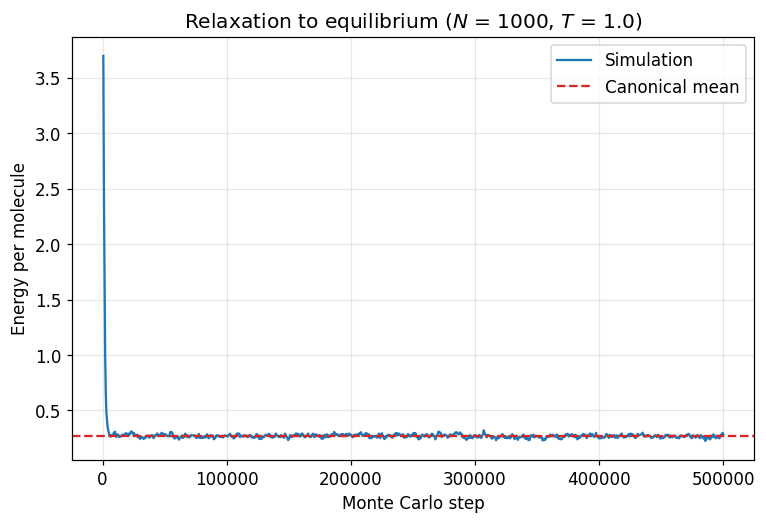

mean energy per molecule, 2nd half of the run: 0.2673 (theory 0.2693)


In [11]:
# Equilibration check: follow the energy per molecule from the (far-from-equilibrium) uniform start.
N, T = 1000, 1.0
rng = np.random.default_rng(SEED + 1)
traj = run_metropolis(N, T, n_equil=0, n_meas=500_000, rng=rng, stride=500)
steps = np.arange(1, len(traj) + 1) * 500
energy_per_molecule = traj @ ENERGIES / N

fig, ax = plt.subplots()
ax.plot(steps, energy_per_molecule, label="Simulation")
ax.axhline(mean_energy_per_molecule(T), color="tab:red", linestyle="--", label="Canonical mean")
ax.set_xlabel("Monte Carlo step")
ax.set_ylabel("Energy per molecule")
ax.set_title(f"Relaxation to equilibrium ($N$ = {N}, $T$ = {T})")
ax.legend()
fig.savefig(f"{FIG_DIR}/equilibration_energy.png")
plt.show()

second_half = energy_per_molecule[len(energy_per_molecule) // 2:]
print(f"mean energy per molecule, 2nd half of the run: {second_half.mean():.4f} "
      f"(theory {mean_energy_per_molecule(T):.4f})")

### Q7 — Mean occupation of the levels vs temperature

For each temperature the system is equilibrated for 200 000 steps (discarded) and the populations are then averaged over 300 000 steps, with $N = 1000$.

The upper level starts to be populated when the expected number of molecules in it, $N e^{-10/T}$, becomes of order one. This defines the characteristic temperature

$$T_c \simeq \frac{10}{\ln N}\;\;\Rightarrow\;\; T_c \approx 1.45 \quad (N = 1000),$$

obtained in Problem 35 of the course problem set.

40 temperatures simulated in 12 s
T_c = 10 / ln N = 1.448
max |simulation - theory| over all levels and temperatures: 0.0025


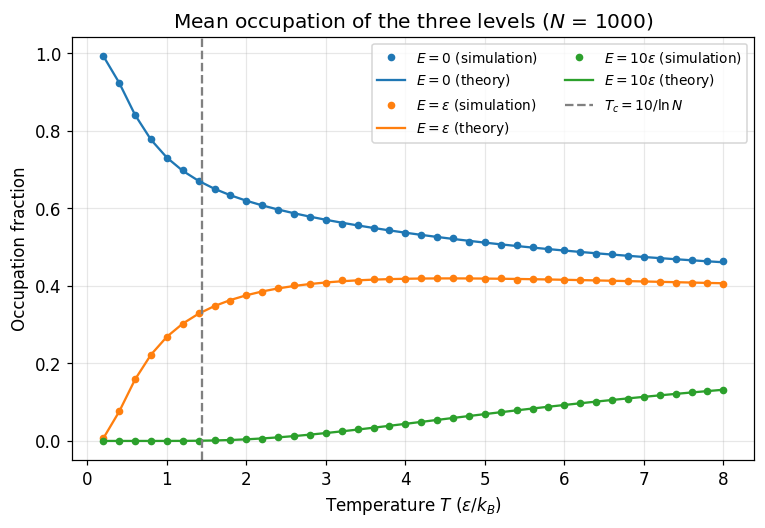

In [12]:
# Mean occupation of each level vs temperature (N = 1000)
N = 1000
N_EQUIL, N_MEAS = 200_000, 300_000          # equilibration is discarded; ~300 relaxation times are measured
temperatures = np.linspace(0.2, 8.0, 40)
T_c = 10.0 / np.log(N)                      # temperature at which N exp(-10/T) ~ 1

rng = np.random.default_rng(SEED + 2)
t0 = time.time()
occ_sim = np.array([run_metropolis(N, T, N_EQUIL, N_MEAS, rng).mean(axis=0) / N for T in temperatures])
occ_theory = np.array([boltzmann_occupations(T) for T in temperatures])
print(f"{len(temperatures)} temperatures simulated in {time.time() - t0:.0f} s")
print(f"T_c = 10 / ln N = {T_c:.3f}")
print(f"max |simulation - theory| over all levels and temperatures: {np.abs(occ_sim - occ_theory).max():.4f}")

fig, ax = plt.subplots()
labels = ["$E = 0$", "$E = \\varepsilon$", "$E = 10\\varepsilon$"]
for k, (lab, c) in enumerate(zip(labels, ["tab:blue", "tab:orange", "tab:green"])):
    ax.plot(temperatures, occ_sim[:, k], "o", color=c, markersize=4, label=f"{lab} (simulation)")
    ax.plot(temperatures, occ_theory[:, k], "-", color=c, label=f"{lab} (theory)")
ax.axvline(T_c, linestyle="--", color="gray", label="$T_c = 10/\\ln N$")
ax.set_xlabel("Temperature $T$ ($\\varepsilon / k_B$)")
ax.set_ylabel("Occupation fraction")
ax.set_title(f"Mean occupation of the three levels ($N$ = {N})")
ax.legend(ncol=2, fontsize=9)
fig.savefig(f"{FIG_DIR}/occupations_vs_T.png")
plt.show()

**Results**

- Simulation and canonical theory agree within statistical noise (maximum deviation ≲ 0.003 in the occupation fraction over all levels and temperatures).
- For $T \ll T_c$ practically all molecules are in the ground level and the top level is empty; the system behaves as an effective two-level system.
- At $T_c$ the expected number of molecules in the top level is $N p_2 \approx 0.7$, i.e. of order one: this is the temperature at which the third level stops being negligible. Above it, its population grows steadily.
- For $T \gg 10$ the three occupations tend to $1/3$. At $T = 8$ this limit has not yet been reached because $T$ is still comparable to the largest gap.

### Q8 — Energy fluctuations as a function of $N$

For independent molecules the total-energy variance is additive,

$$\langle(\Delta E)^2\rangle = N\,\langle(\Delta e)^2\rangle,\qquad \langle(\Delta e)^2\rangle = \langle e^2\rangle - \langle e\rangle^2,$$

with $\langle e\rangle = (e^{-1/T} + 10e^{-10/T})/z$ and $\langle e^2\rangle = (e^{-1/T} + 100e^{-10/T})/z$. Since $\langle E\rangle = N\langle e\rangle$, the relative fluctuation scales as

$$\frac{\sigma_E}{\langle E\rangle} = \frac{\sqrt{\langle(\Delta e)^2\rangle}}{\langle e\rangle}\,\frac{1}{\sqrt N}.$$

Each value of $N$ is simulated at $T = 2$ with 5 independent runs (different random streams) to obtain error bars. The equilibration and measurement lengths grow with $N$ (200 N and 600 N steps) because the relaxation time of the chain is proportional to $N$, and the energy is sampled every $N/10$ steps.

In [13]:
# Energy fluctuations vs N at fixed T
T = 2.0
Ns = np.array([100, 200, 500, 1000, 2000, 5000])
N_REPLICAS = 5                              # independent runs per N -> error bars
EQUIL_FACTOR, MEAS_FACTOR = 200, 600        # steps = factor * N (the correlation time scales as N)

child_seeds = np.random.SeedSequence(SEED + 3).spawn(len(Ns) * N_REPLICAS)
var_runs, mean_runs = np.zeros((len(Ns), N_REPLICAS)), np.zeros((len(Ns), N_REPLICAS))

t0 = time.time()
for a, N in enumerate(Ns):
    for r in range(N_REPLICAS):
        rng = np.random.default_rng(child_seeds[a * N_REPLICAS + r])
        pops = run_metropolis(N, T, EQUIL_FACTOR * N, MEAS_FACTOR * N, rng, stride=max(1, N // 10))
        E_total = pops @ ENERGIES
        mean_runs[a, r], var_runs[a, r] = E_total.mean(), E_total.var()
print(f"done in {time.time() - t0:.0f} s")

var_sim, var_err = var_runs.mean(axis=1), var_runs.std(axis=1, ddof=1) / np.sqrt(N_REPLICAS)
var_theory = Ns * energy_variance_per_molecule(T)
rel_sim = np.sqrt(var_runs) / mean_runs                   # sigma_E / <E> in every replica
rel_mean, rel_err = rel_sim.mean(axis=1), rel_sim.std(axis=1, ddof=1) / np.sqrt(N_REPLICAS)
rel_theory = np.sqrt(energy_variance_per_molecule(T)) / (mean_energy_per_molecule(T) * np.sqrt(Ns))

print(f"\n{'N':>6} {'Var(E) sim':>13} {'Var(E) theory':>14} {'sigma/<E> sim':>14} {'theory':>8}")
for i, N in enumerate(Ns):
    print(f"{N:6d} {var_sim[i]:8.1f} +/-{var_err[i]:5.1f} {var_theory[i]:14.1f} "
          f"{rel_mean[i]:14.4f} {rel_theory[i]:8.4f}")

exponent = np.polyfit(np.log(Ns), np.log(rel_mean), 1)[0]
print(f"\nFitted exponent of sigma_E/<E> vs N: {exponent:.3f}   (theory: -0.5)")

done in 15 s

     N    Var(E) sim  Var(E) theory  sigma/<E> sim   theory
   100     59.1 +/-  1.8           61.9         0.1843   0.1884
   200    121.5 +/-  4.3          123.8         0.1319   0.1332
   500    317.3 +/- 10.4          309.6         0.0853   0.0842
  1000    619.7 +/- 18.1          619.1         0.0596   0.0596
  2000   1273.9 +/- 16.8         1238.2         0.0427   0.0421
  5000   3091.2 +/- 43.9         3095.6         0.0266   0.0266

Fitted exponent of sigma_E/<E> vs N: -0.494   (theory: -0.5)


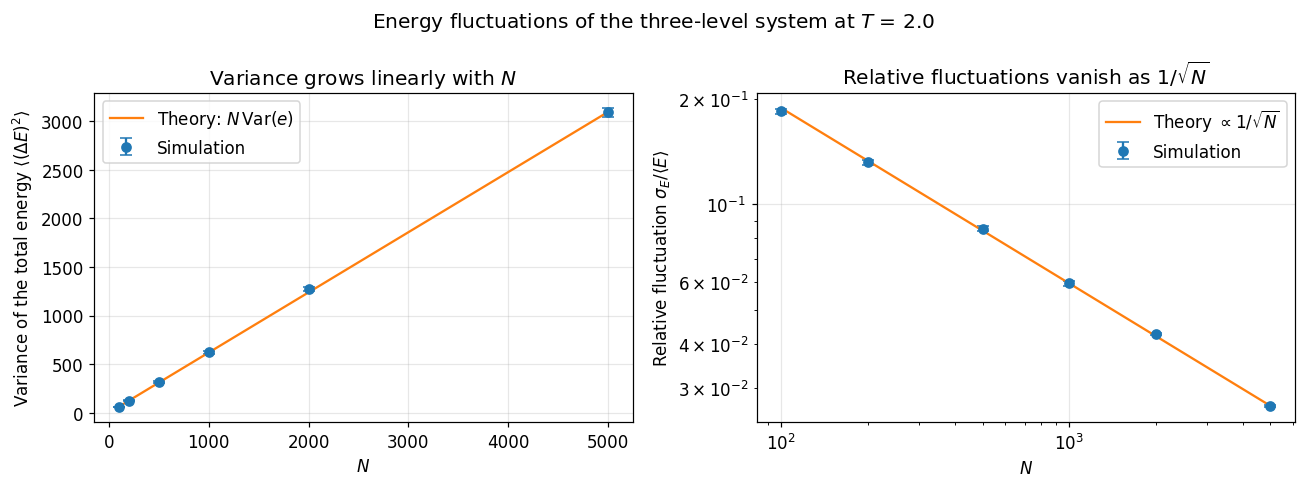

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.errorbar(Ns, var_sim, yerr=var_err, fmt="o", capsize=4, label="Simulation")
ax.plot(Ns, var_theory, "-", label=r"Theory: $N\,\mathrm{Var}(e)$")
ax.set_xlabel("$N$")
ax.set_ylabel(r"Variance of the total energy $\langle(\Delta E)^2\rangle$")
ax.set_title("Variance grows linearly with $N$")
ax.legend()

ax = axes[1]
ax.errorbar(Ns, rel_mean, yerr=rel_err, fmt="o", capsize=4, label="Simulation")
ax.plot(Ns, rel_theory, "-", label=r"Theory $\propto 1/\sqrt{N}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$N$")
ax.set_ylabel(r"Relative fluctuation $\sigma_E / \langle E\rangle$")
ax.set_title("Relative fluctuations vanish as $1/\\sqrt{N}$")
ax.legend()

fig.suptitle(f"Energy fluctuations of the three-level system at $T$ = {T}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/energy_fluctuations.png")
plt.show()

**Results**

- The variance of the total energy grows linearly with $N$ and matches $N\langle(\Delta e)^2\rangle$ within the error bars.
- The relative fluctuation decreases as $N^{-1/2}$; the fitted exponent is close to $-0.5$.
- Interpretation: absolute fluctuations grow with system size, but more slowly than the mean energy. In the thermodynamic limit $N \to \infty$ the relative fluctuations vanish and the canonical average describes the macroscopic state precisely.

## Notes and limitations

- **Part A** uses a small set of $(T,\rho)$ points with sizeable statistical errors; $\kappa_T$ obtained from numerical derivatives of such data is intrinsically noisy, especially for the liquid and at low temperature.
- **Part B** is a fully controlled test case (exact solution available), which is why the simulation can be validated quantitatively. Statistical errors in Q8 are estimated from independent replicas.
- Results are reproducible: all random numbers derive from the master seed `SEED` defined in the setup cell.

## References

- Course material of *Termodinàmica i Mecànica Estadística* (UAB), including the Lennard-Jones simulator used for Parts A and Q4 and the problem set (Problem 35).
- N. Metropolis, A. W. Rosenbluth, M. N. Rosenbluth, A. H. Teller and E. Teller, *J. Chem. Phys.* **21**, 1087 (1953).
- D. Frenkel and B. Smit, *Understanding Molecular Simulation*, Academic Press.
- Hard-sphere gas scripts adapted from the VPython example by Bruce Sherwood (see `src/hard_sphere_gas/`).